# SGD Model Predictions Visualization

Visualize pixel-wise predictions from the SGD classifier across all years.
Compare predictions (with custom colormap) to ground truth labels with forest mask overlay.

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import zarr
import pickle
import random
from pathlib import Path



In [90]:
# Runtime profile configuration
MODEL_PROFILE = 'monthly'  # Options: 'monthly', 'lagged', 'base'

PROFILE_CONFIGS = {
    'monthly': {
        'models_dir': Path('models_prevyears_monthly_features'),
        'model_filename': 'model_year_{year}_prevyears_monthly_features.pkl',
        'scaler_filename': 'scaler_year_{year}_prevyears_monthly_features.pkl',
        'features_zarr': Path('training_data_with_features_plus_monthly_indices.zarr'),
        'output_dir': Path('prediction visualizations prevyears monthly features'),
    },
    'lagged': {
        'models_dir': Path('models_lagged_features'),
        'model_filename': 'model_year_{year}_lagged_features.pkl',
        'scaler_filename': 'scaler_year_{year}_lagged_features.pkl',
        'features_zarr': Path('training_data_with_features.zarr'),
        'output_dir': Path('prediction visualizations lagged features'),
    },
    'base': {
        'models_dir': Path('models'),
        'model_filename': 'model_year_{year}.pkl',
        'scaler_filename': 'scaler_year_{year}.pkl',
        'features_zarr': Path('training_data_with_features.zarr'),
        'output_dir': Path('prediction visualizations base'),
    },
}

if MODEL_PROFILE not in PROFILE_CONFIGS:
    valid_profiles = ', '.join(sorted(PROFILE_CONFIGS))
    raise ValueError(f"Unknown MODEL_PROFILE '{MODEL_PROFILE}'. Choose one of: {valid_profiles}")

ACTIVE_PROFILE = PROFILE_CONFIGS[MODEL_PROFILE]
MODELS_DIR = ACTIVE_PROFILE['models_dir']
MODEL_FILENAME_TEMPLATE = ACTIVE_PROFILE['model_filename']
SCALER_FILENAME_TEMPLATE = ACTIVE_PROFILE['scaler_filename']
FEATURES_ZARR_PATH = ACTIVE_PROFILE['features_zarr']
OUTPUT_DIR = ACTIVE_PROFILE['output_dir']

print('=' * 70)
print(f"Using profile: {MODEL_PROFILE}")
print(f"Models directory: {MODELS_DIR}")
print(f"Model filename template: {MODEL_FILENAME_TEMPLATE}")
print(f"Scaler filename template: {SCALER_FILENAME_TEMPLATE}")
print(f"Features dataset: {FEATURES_ZARR_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Models directory exists: {MODELS_DIR.exists()}")
print(f"Features dataset exists: {FEATURES_ZARR_PATH.exists()}")
print('=' * 70)

Using profile: monthly
Models directory: models_prevyears_monthly_features
Model filename template: model_year_{year}_prevyears_monthly_features.pkl
Scaler filename template: scaler_year_{year}_prevyears_monthly_features.pkl
Features dataset: training_data_with_features_plus_monthly_indices.zarr
Output directory: prediction visualizations prevyears monthly features
Models directory exists: True
Features dataset exists: True


In [91]:
# Load data splits
data_split = np.load('data_split.npz', allow_pickle=True)
test_cube_indices = data_split['test_cube_indices']
test_pixel_indices = data_split['test_pixel_indices']

# Load cube names if available (for name-based lookups)
try:
    test_cube_names = data_split['test_cube_names']
    print(f"Test cubes available: {len(test_cube_names)} (by name)")
    print(f"Test cube names sample: {test_cube_names[:5]}")
except KeyError:
    test_cube_names = None
    print(f"Test cubes available: {len(test_cube_indices)} (numeric indices only)")
    print(f"Test cube indices sample: {test_cube_indices[:5]}")

print(f"Test pixels total: {len(test_pixel_indices)}")

Test cubes available: 297 (numeric indices only)
Test cube indices sample: [1825 1735  678  351 1791]
Test pixels total: 1283992


In [92]:
# Load training data (contains x, y, cube_idx, disturbances, etc.)
training_data = zarr.open('training_data.zarr', mode='r')

print("Training data variables:")
print(training_data.keys())
print(f"\nTraining data dimensions: {training_data['cube_idx'].shape}")
print(f"Example cube indices: {training_data['cube_idx'][:10]}")
print(f"Example x coordinates: {training_data['x'][:10]}")
print(f"Example y coordinates: {training_data['y'][:10]}")

Training data variables:
<generator object Group.keys at 0x000001EC1F5386C0>

Training data dimensions: (8155205,)
Example cube indices: [0 0 0 0 0 0 0 0 0 0]
Example x coordinates: [ 55 101  46  42 106   7  58   3   9  12]
Example y coordinates: [59 32 98 90 35 91 17 83  8 94]


In [93]:
# Load full dataset for forest mask
full_dataset = zarr.open('full_dataset_resizedv2.zarr', mode='r')

print("Full dataset variables:")
print(list(full_dataset.keys()))

# Load cube names from full dataset for mapping
full_dataset_cube_names = np.array(full_dataset['cube'][:])
print(f"Full dataset has {len(full_dataset_cube_names)} cubes")
print(f"Sample cube names: {full_dataset_cube_names[:5]}")

def map_training_idx_to_full(training_cube_idx):
    """Map training cube index to full_dataset index using cube names"""
    # Find a pixel with this training cube index
    pixels_with_idx = np.where(training_data['cube_idx'][:] == training_cube_idx)[0]
    if len(pixels_with_idx) == 0:
        raise ValueError(f"No training pixels found with cube_idx={training_cube_idx}")
    
    # Get the cube name
    pixel_idx = pixels_with_idx[0]
    cube_name = training_data['cube_name'][pixel_idx]
    print(f"Training cube_idx {training_cube_idx} → cube_name '{cube_name}'")
    
    # Find this cube in full_dataset
    full_cube_idx = np.where(full_dataset_cube_names == cube_name)[0]
    if len(full_cube_idx) == 0:
        raise ValueError(f"Cube name '{cube_name}' not found in full_dataset")
    
    return full_cube_idx[0]

Full dataset variables:
['S2', 'S2_norm', 'SCL', 'SCL_count', 'SCL_count_norm', 'anyhist_disturbances', 'cloudmask', 'cube', 'dem', 'dem_norm', 'disturbance_agent', 'disturbance_prob', 'disturbances', 'forest_mask', 'forest_mask_static', 'hist_disturbances', 'lccs_class', 'norm', 'original_x', 'original_x_300', 'original_y', 'original_y_300', 'pos', 'position', 's2_band', 'scl_class', 'spatial_ref', 'statistic', 'time', 'topK', 'weather', 'weather_band', 'weather_norm', 'weather_stats', 'weather_stats_norm', 'x', 'x_300', 'y', 'y_300', 'year']
Full dataset has 2216 cubes
Sample cube names: ['mc_-0.04_51.09_1.2_20230627_0' 'mc_-0.06_44.09_1.2_20230627_0'
 'mc_-0.06_51.21_1.2_20230627_0' 'mc_-0.28_45.20_1.2_20230627_0'
 'mc_-0.43_44.22_1.2_20230627_0']


In [94]:
# ==================================================
# OPTION 1: Select a random test cube (uncomment below)
# ==================================================
use_random = True  # Set to False to use specific cube instead

if use_random:
    selected_training_cube_idx = np.random.choice(test_cube_indices)
    print(f"Selected random training cube index: {selected_training_cube_idx}")
else:
    # ==================================================
    # OPTION 2: Specify a particular cube index (edit below)
    # ==================================================
    selected_training_cube_idx = 196  # ← CHANGE THIS to your desired cube index
    
    if selected_training_cube_idx not in test_cube_indices:
        print(f"ERROR: Cube index {selected_training_cube_idx} is not in test set!")
        print(f"Available test cube indices: {sorted(test_cube_indices)[:40]}...")
        raise ValueError(f"Cube {selected_training_cube_idx} not in test set")
    
    print(f"Selected specific training cube index: {selected_training_cube_idx}")

# Get the cube name from training data
pixels_with_idx = np.where(training_data['cube_idx'][:] == selected_training_cube_idx)[0]
selected_cube_name = training_data['cube_name'][pixels_with_idx[0]]
print(f"Selected cube name: '{selected_cube_name}'")

# Map to full_dataset index
selected_full_cube_idx = map_training_idx_to_full(selected_training_cube_idx)
print(f"Full dataset cube index: {selected_full_cube_idx}")

# Find all pixels from this cube in the training data (across all years)
cube_pixels_mask = training_data['cube_idx'][:] == selected_training_cube_idx
cube_pixels_indices = np.where(cube_pixels_mask)[0]

print(f"Total pixels from this cube in training data: {len(cube_pixels_indices)}")

Selected random training cube index: 593
Selected cube name: 'mc_15.24_58.63_1.3_20231018_0'
Training cube_idx 593 → cube_name 'mc_15.24_58.63_1.3_20231018_0'
Full dataset cube index: 672
Total pixels from this cube in training data: 11599


In [95]:
# Extract spatial information for this cube
x_coords = training_data['x'][cube_pixels_indices]
y_coords = training_data['y'][cube_pixels_indices]

# Check year structure
print(f"Year shape: {training_data['year'].shape}")
print(f"Year sample values: {training_data['year'][:]}")

print(f"X coordinates range: {x_coords.min()} to {x_coords.max()}")
print(f"Y coordinates range: {y_coords.min()} to {y_coords.max()}")

# Get unique coordinates to determine grid size
unique_x = np.unique(x_coords)
unique_y = np.unique(y_coords)
print(f"Unique X values: {len(unique_x)}, Unique Y values: {len(unique_y)}")

Year shape: (7,)
Year sample values: [2016 2017 2018 2019 2020 2021 2022]
X coordinates range: 0 to 127
Y coordinates range: 0 to 127
Unique X values: 128, Unique Y values: 128


In [96]:
# Load forest masks for all years for the selected cube (use full_dataset index)
forest_masks_by_year = full_dataset['forest_mask'][selected_full_cube_idx, :, :, :]
print(f"Forest masks shape (all years): {forest_masks_by_year.shape}")
print(f"Forest mask unique values: {np.unique(forest_masks_by_year)}")
print(f"Loading forest mask for cube: '{selected_cube_name}' (full_dataset[{selected_full_cube_idx}])")

# Check if forest mask is static across years
is_static = np.all(forest_masks_by_year == forest_masks_by_year[0])
print(f"Forest mask is static across years: {is_static}")

# Also load the forest_mask_static if available
try:
    forest_mask_static = full_dataset['forest_mask_static'][selected_full_cube_idx, :, :]
    print(f"Forest mask static shape: {forest_mask_static.shape}")
except:
    forest_mask_static = None
    print("Forest mask static not available")

Forest masks shape (all years): (7, 128, 128)
Forest mask unique values: [0 1]
Loading forest mask for cube: 'mc_15.24_58.63_1.3_20231018_0' (full_dataset[672])
Forest mask is static across years: False
Forest mask static shape: (128, 128)


In [97]:
def create_custom_colormap():
    """
    Create custom colormap for prediction probabilities:
    Continuous spectrum from green (prob=0) to red (prob=1)
    """
    from matplotlib.colors import LinearSegmentedColormap
    
    # Create continuous colormap from green to red
    colors = ['green', 'red']
    n_bins = 256
    cmap = LinearSegmentedColormap.from_list('green_red', colors, N=n_bins)
    norm = None  # Use default normalization (0 to 1)
    
    return cmap, norm

# Test the colormap
cmap, norm = create_custom_colormap()
print("Custom colormap created successfully")

Custom colormap created successfully


In [98]:
def create_spatial_grids(x_coords, y_coords, values, grid_shape=None):
    """
    Create spatial grids from scattered pixel coordinates and values.
    Only pixels in the training set will have values; others will be NaN.
    """
    if grid_shape is None:
        max_x = int(x_coords.max()) + 1
        max_y = int(y_coords.max()) + 1
        grid_shape = (max_y, max_x)
    
    grid = np.full(grid_shape, np.nan)
    
    for i, (x, y, val) in enumerate(zip(x_coords, y_coords, values)):
        x_idx = int(x)
        y_idx = int(y)
        if 0 <= y_idx < grid_shape[0] and 0 <= x_idx < grid_shape[1]:
            grid[y_idx, x_idx] = val
    
    return grid

# Determine full grid shape
max_x = int(x_coords.max()) + 1
max_y = int(y_coords.max()) + 1
grid_shape = (max_y, max_x)
print(f"Grid shape will be: {grid_shape}")

Grid shape will be: (128, 128)


In [99]:
# Load feature dataset based on the active profile
required_profile_vars = ['MODEL_PROFILE', 'FEATURES_ZARR_PATH', 'MODELS_DIR', 'OUTPUT_DIR']
missing_profile_vars = [name for name in required_profile_vars if name not in globals()]
if missing_profile_vars:
    missing_str = ', '.join(missing_profile_vars)
    raise RuntimeError(
        f"Profile configuration variables missing: {missing_str}. Run the profile configuration cell first."
    )

training_data_features = zarr.open(str(FEATURES_ZARR_PATH), mode='r')
feature_variable_names = list(training_data_features.keys())

print('Runtime summary:')
print(f"  Profile: {MODEL_PROFILE}")
print(f"  Feature dataset: {FEATURES_ZARR_PATH}")
print(f"  Models directory: {MODELS_DIR}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Available feature variables: {len(feature_variable_names)}")
print(f"  Feature dimensions (dem): {training_data_features['dem'].shape}")

Runtime summary:
  Profile: monthly
  Feature dataset: training_data_with_features_plus_monthly_indices.zarr
  Models directory: models_prevyears_monthly_features
  Output directory: prediction visualizations prevyears monthly features
  Available feature variables: 30
  Feature dimensions (dem): (8155205, 7)


In [100]:
import re

def _template_to_glob(template):
    return template.replace('{year}', '*')

def _template_to_regex(template):
    escaped = re.escape(template)
    pattern = escaped.replace(r'\{year\}', r'(?P<year>\d{4})')
    return re.compile(f'^{pattern}$')

MODEL_FILENAME_REGEX = _template_to_regex(MODEL_FILENAME_TEMPLATE)
SCALER_FILENAME_REGEX = _template_to_regex(SCALER_FILENAME_TEMPLATE)

def _extract_year_from_filename(name, pattern):
    match = pattern.match(name)
    if not match:
        return None
    try:
        return int(match.group('year'))
    except (TypeError, ValueError):
        return None

def _artifact_path(year, artifact_type):
    year = int(year)
    if artifact_type == 'model':
        filename = MODEL_FILENAME_TEMPLATE.format(year=year)
    elif artifact_type == 'scaler':
        filename = SCALER_FILENAME_TEMPLATE.format(year=year)
    else:
        raise ValueError(f"Unknown artifact_type '{artifact_type}'")
    return MODELS_DIR / filename

def load_year_model(year):
    """Load the model trained for a specific year."""
    model_path = _artifact_path(year, 'model')
    if not model_path.exists():
        print(f"Warning: Model for year {year} not found at {model_path}")
        return None

    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    return model

def load_year_scaler(year):
    """Load the scaler fitted for a specific year."""
    scaler_path = _artifact_path(year, 'scaler')
    if not scaler_path.exists():
        print(f"Warning: Scaler for year {year} not found at {scaler_path}")
        return None

    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    return scaler

# Cache for loaded scalers to avoid redundant disk reads
year_scaler_cache = {}

def get_scaler_for_year(year):
    """Get scaler for a year, using cache to avoid reloading."""
    if year not in year_scaler_cache:
        year_scaler_cache[year] = load_year_scaler(year)
    return year_scaler_cache[year]

# Check which year models and scalers are available for this profile
model_years = set()
scaler_years = set()
model_glob = _template_to_glob(MODEL_FILENAME_TEMPLATE)
scaler_glob = _template_to_glob(SCALER_FILENAME_TEMPLATE)

if MODELS_DIR.exists():
    for path in MODELS_DIR.glob(model_glob):
        year = _extract_year_from_filename(path.name, MODEL_FILENAME_REGEX)
        if year is not None:
            model_years.add(year)
    for path in MODELS_DIR.glob(scaler_glob):
        year = _extract_year_from_filename(path.name, SCALER_FILENAME_REGEX)
        if year is not None:
            scaler_years.add(year)

dataset_years = {int(y) for y in np.array(training_data['year'][:]).tolist()}
available_years = sorted((model_years & scaler_years) & dataset_years)

print(f"Profile '{MODEL_PROFILE}' loader settings:")
print(f"  Models directory: {MODELS_DIR}")
print(f"  Model glob: {model_glob}")
print(f"  Scaler glob: {scaler_glob}")
print(f"  Dataset years: {sorted(dataset_years)}")

if not MODELS_DIR.exists():
    print(f"Models directory not found: {MODELS_DIR}")
else:
    all_artifact_years = sorted(model_years | scaler_years)
    if not all_artifact_years:
        print("No model/scaler artifacts matched the configured filename templates.")
    for year in all_artifact_years:
        has_model = year in model_years
        has_scaler = year in scaler_years
        in_dataset = year in dataset_years
        status = '✓ model and scaler available' if (has_model and has_scaler) else '✗ incomplete artifacts'
        dataset_tag = ' | in dataset' if in_dataset else ' | not in dataset years'
        print(f"Year {year}: {status}{dataset_tag}")

print(f"\nAvailable year pairs for visualization: {available_years}")

Profile 'monthly' loader settings:
  Models directory: models_prevyears_monthly_features
  Model glob: model_year_*_prevyears_monthly_features.pkl
  Scaler glob: scaler_year_*_prevyears_monthly_features.pkl
  Dataset years: [2016, 2017, 2018, 2019, 2020, 2021, 2022]
Year 2017: ✓ model and scaler available | in dataset
Year 2018: ✓ model and scaler available | in dataset
Year 2019: ✓ model and scaler available | in dataset
Year 2020: ✓ model and scaler available | in dataset
Year 2021: ✓ model and scaler available | in dataset
Year 2022: ✓ model and scaler available | in dataset

Available year pairs for visualization: [2017, 2018, 2019, 2020, 2021, 2022]


In [101]:
def extract_features_for_cube_year(cube_pixels_indices, year_idx, training_data_features):
    """
    Extract feature vectors for a cube at a specific year.
    Returns features array suitable for model prediction.
    NaN values are filled with 0 for prediction.
    """
    # Get S2 bands (all bands for this year)
    s2_bands = training_data_features['s2_bands'][cube_pixels_indices, year_idx, :].astype(np.float64)

    # Get DEM (same for all years, take from year_idx anyway)
    dem = training_data_features['dem'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)

    # Get spectral indices
    ndvi = training_data_features['ndvi'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
    ndwi = training_data_features['ndwi'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)

    features_list = [s2_bands, dem, ndvi, ndwi]

    # Last-year features (year t-1)
    if year_idx > 0:
        ndvi_last_year = training_data_features['ndvi'][cube_pixels_indices, year_idx-1:year_idx].astype(np.float64)
        ndwi_last_year = training_data_features['ndwi'][cube_pixels_indices, year_idx-1:year_idx].astype(np.float64)
        ndvi_last_year = np.nan_to_num(ndvi_last_year, nan=0.0)
        ndwi_last_year = np.nan_to_num(ndwi_last_year, nan=0.0)
    else:
        ndvi_last_year = np.zeros((len(cube_pixels_indices), 1))
        ndwi_last_year = np.zeros((len(cube_pixels_indices), 1))

    features_list.extend([ndvi_last_year, ndwi_last_year])

    # Last-year selected S2 bands
    required_last_year_bands = ['B04', 'B03', 'B06']
    band_labels = training_data_features['s2_band'][:] if 's2_band' in training_data_features else []
    band_labels = [b.decode('utf-8') if isinstance(b, (bytes, np.bytes_)) else str(b) for b in band_labels]
    band_to_idx = {band: i for i, band in enumerate(band_labels)}
    missing_bands = [band for band in required_last_year_bands if band not in band_to_idx]
    if missing_bands:
        raise ValueError(f"Missing required S2 bands for last-year features: {missing_bands}")

    if year_idx > 0:
        for band in required_last_year_bands:
            band_idx = band_to_idx[band]
            band_values = training_data_features['s2_bands'][cube_pixels_indices, year_idx-1, band_idx].astype(np.float64)
            band_values = np.nan_to_num(band_values, nan=0.0)
            features_list.append(band_values.reshape(-1, 1))
    else:
        for _ in required_last_year_bands:
            features_list.append(np.zeros((len(cube_pixels_indices), 1)))

    # Add NBR if available
    if 'nbr' in training_data_features:
        nbr = training_data_features['nbr'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
        features_list.append(nbr)

    # Temporal deltas (offset by one year index)
    if year_idx > 0 and 'ndvi_delta' in training_data_features:
        delta_year_idx = year_idx - 1
        ndvi_delta = training_data_features['ndvi_delta'][cube_pixels_indices, delta_year_idx:delta_year_idx+1].astype(np.float64)
        ndwi_delta = training_data_features['ndwi_delta'][cube_pixels_indices, delta_year_idx:delta_year_idx+1].astype(np.float64)
        features_list.extend([ndvi_delta, ndwi_delta])
        if 'nbr_delta' in training_data_features:
            nbr_delta = training_data_features['nbr_delta'][cube_pixels_indices, delta_year_idx:delta_year_idx+1].astype(np.float64)
            features_list.append(nbr_delta)
    else:
        if 'ndvi_delta' in training_data_features:
            features_list.extend([
                np.zeros((len(cube_pixels_indices), 1)),
                np.zeros((len(cube_pixels_indices), 1))
            ])
            if 'nbr_delta' in training_data_features:
                features_list.append(np.zeros((len(cube_pixels_indices), 1)))

    # Temporal features
    if 'years_since_last_disturbance' in training_data_features:
        years_since = training_data_features['years_since_last_disturbance'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
        features_list.append(years_since)
    if 'log_years_since_last_disturbance' in training_data_features:
        log_years_since = training_data_features['log_years_since_last_disturbance'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
        features_list.append(log_years_since)
    if 'ever_disturbed' in training_data_features:
        ever_disturbed = training_data_features['ever_disturbed'][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
        features_list.append(ever_disturbed)

    # Monthly profile adds yearly summary index features in this exact order.
    yearly_index_feature_names = [
        'ndvi_cv_year',
        'ndvi_max_m2m_drop_year',
        'ndvi_max_year',
        'ndvi_min_year',
        'ndvi_std_year',
        'ndwi_cv_year',
        'ndwi_max_m2m_drop_year',
        'ndwi_max_year',
        'ndwi_min_year',
        'ndwi_std_year',
    ]
    for feature_name in yearly_index_feature_names:
        if feature_name in training_data_features:
            feature_values = training_data_features[feature_name][cube_pixels_indices, year_idx:year_idx+1].astype(np.float64)
            features_list.append(feature_values)

    # Concatenate all features (match training order)
    features = np.hstack(features_list)

    # For prediction, impute NaN values with 0
    features_for_pred = features.copy()
    features_for_pred[np.isnan(features_for_pred)] = 0.0

    # Return both: features_for_pred (for model) and original features (to track NaNs)
    return features_for_pred, features

print('Feature extraction function aligned with monthly yearly-index features')

Feature extraction function aligned with monthly yearly-index features


In [102]:
# Create a mapping from year values to year indices
year_values = training_data['year'][:]
year_to_idx = {year: idx for idx, year in enumerate(year_values)}

print(f"Year mapping: {year_to_idx}")

# Get ground truth disturbances for all pixels in this cube (all years)
disturbances_all = training_data_features['disturbances'][cube_pixels_indices, :]
print(f"Disturbances shape for cube: {disturbances_all.shape}")

Year mapping: {2016: 0, 2017: 1, 2018: 2, 2019: 3, 2020: 4, 2021: 5, 2022: 6}
Disturbances shape for cube: (11599, 7)


In [103]:
def create_forest_mask_overlay(forest_mask_2d, alpha=0.3):
    """
    Create an RGBA overlay for forest mask.
    Light purple (for forest=1) with alpha transparency.
    """
    overlay = np.zeros((*forest_mask_2d.shape, 4), dtype=np.float32)
    # For forest pixels (value=1), set to light purple with transparency
    forest_pixels = forest_mask_2d == 1
    overlay[forest_pixels, :] = [0.8, 0.5, 0.8, alpha]  # Light purple (RGBA)
    return overlay

print("Forest mask overlay function created")

Forest mask overlay function created


In [104]:
def create_spatial_grid_with_nan(x_coords, y_coords, values, grid_shape=None):
    """
    Create spatial grid preserving NaN values.
    Pixels not in the training set or with NaN values remain NaN.
    """
    if grid_shape is None:
        max_x = int(x_coords.max()) + 1
        max_y = int(y_coords.max()) + 1
        grid_shape = (max_y, max_x)

    grid = np.full(grid_shape, np.nan)

    for i, (x, y, val) in enumerate(zip(x_coords, y_coords, values)):
        x_idx = int(x)
        y_idx = int(y)
        if 0 <= y_idx < grid_shape[0] and 0 <= x_idx < grid_shape[1]:
            grid[y_idx, x_idx] = val

    return grid

def visualize_year(year, year_idx, model, scaler, cube_pixels_indices, x_coords, y_coords, 
                   disturbances_all, forest_mask_year, grid_shape, cmap, norm):
    """
    Create visualization for a specific year.
    Shows predictions vs ground truth side by side.
    NaNs are displayed as black.
    Uses the forest mask for the specific year.

    Args:
        year: Year value (e.g., 2017)
        year_idx: Year index (0-based)
        model: Trained model for the year
        scaler: Fitted scaler for the year
        cube_pixels_indices: Indices of pixels in the cube
        x_coords, y_coords: Spatial coordinates of cube pixels
        disturbances_all: Ground truth disturbances for all pixels/years
        forest_mask_year: Forest mask for this specific year
        grid_shape: Shape of output grid
        cmap: Colormap for visualization
        norm: Normalization for colormap
    """
    # Extract features for this year
    features_for_pred, features_with_nan = extract_features_for_cube_year(cube_pixels_indices, year_idx, training_data_features)

    expected_scaler_features = getattr(scaler, 'n_features_in_', None)
    if expected_scaler_features is not None and features_for_pred.shape[1] != int(expected_scaler_features):
        raise ValueError(
            f"Feature count mismatch for year {year}: extracted {features_for_pred.shape[1]} features "
            f"but scaler expects {int(expected_scaler_features)}. "
            "Check MODEL_PROFILE and FEATURES_ZARR_PATH."
        )

    # Scale features using the year-specific scaler before making predictions
    features_scaled = scaler.transform(features_for_pred)

    # Make predictions
    probabilities = model.predict_proba(features_scaled)[:, 1]  # Probability of class 1 (disturbance)
    ground_truth = disturbances_all[:, year_idx]

    # Mark pixels with NaN in any feature as NaN in output (for visualization)
    has_nan = np.any(np.isnan(features_with_nan), axis=1)
    probabilities_vis = probabilities.copy().astype(np.float64)
    probabilities_vis[has_nan] = np.nan

    # Create spatial grids
    pred_grid = create_spatial_grid_with_nan(x_coords, y_coords, probabilities_vis, grid_shape)
    gt_grid = create_spatial_grid_with_nan(x_coords, y_coords, ground_truth, grid_shape)

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Predictions with NaN as black and forest mask overlay
    im1 = ax1.imshow(pred_grid, cmap=cmap, norm=norm, origin='upper')
    # Add black background for NaN values
    nan_mask = np.isnan(pred_grid)
    black_background = np.zeros((*pred_grid.shape, 3))
    ax1.imshow(np.where(nan_mask[:, :, None], 0, 1), cmap='gray', origin='upper', vmin=0, vmax=1, alpha=0.3)
    forest_overlay = create_forest_mask_overlay(forest_mask_year, alpha=0.2)
    ax1.imshow(forest_overlay, origin='upper')
    ax1.set_title(f'Predictions - {year}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X coordinate')
    ax1.set_ylabel('Y coordinate')
    cbar1 = plt.colorbar(im1, ax=ax1, label='Disturbance Probability')

    # Plot 2: Ground truth with NaN as black and forest mask overlay
    gt_cmap = ListedColormap(['green', 'red'])
    gt_norm = BoundaryNorm([0, 0.5, 1.0], 2)
    im2 = ax2.imshow(gt_grid, cmap=gt_cmap, norm=gt_norm, origin='upper')
    # Add black background for NaN values
    nan_mask_gt = np.isnan(gt_grid)
    ax2.imshow(np.where(nan_mask_gt[:, :, None], 0, 1), cmap='gray', origin='upper', vmin=0, vmax=1, alpha=0.3)
    ax2.imshow(forest_overlay, origin='upper')
    ax2.set_title(f'Ground Truth - {year}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('X coordinate')
    ax2.set_ylabel('Y coordinate')
    cbar2 = plt.colorbar(im2, ax=ax2, label='Disturbance Label', ticks=[0.25, 0.75])
    cbar2.set_ticklabels(['No Disturbance', 'Disturbance'])

    plt.tight_layout()
    return fig, probabilities, ground_truth

print('Visualization function updated with feature-count guard')

Visualization function updated with feature-count guard


Creating visualizations for cube: mc_15.24_58.63_1.3_20231018_0 (training idx: 593)
Cube contains 11599 pixels from training set
Run configuration:
  Profile: monthly
  Models directory: models_prevyears_monthly_features
  Features dataset: training_data_with_features_plus_monthly_indices.zarr
  Output directory: c:\Users\bartu\Desktop\Fonda-scikit\prediction visualizations prevyears monthly features
  Available years (model + scaler + dataset): [2017, 2018, 2019, 2020, 2021, 2022]


Processing year 2017 (index 1)...
  Saved: prediction visualizations prevyears monthly features\mc_15.24_58.63_1.3_20231018_0_2017.png


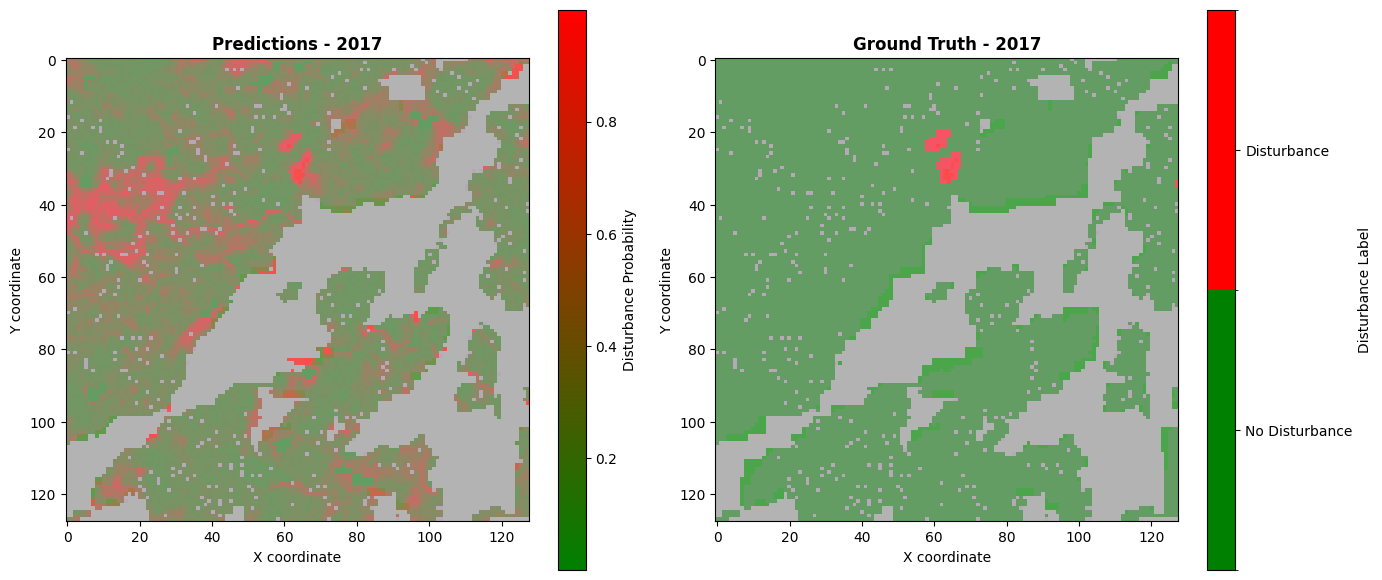


Processing year 2018 (index 2)...
  Saved: prediction visualizations prevyears monthly features\mc_15.24_58.63_1.3_20231018_0_2018.png


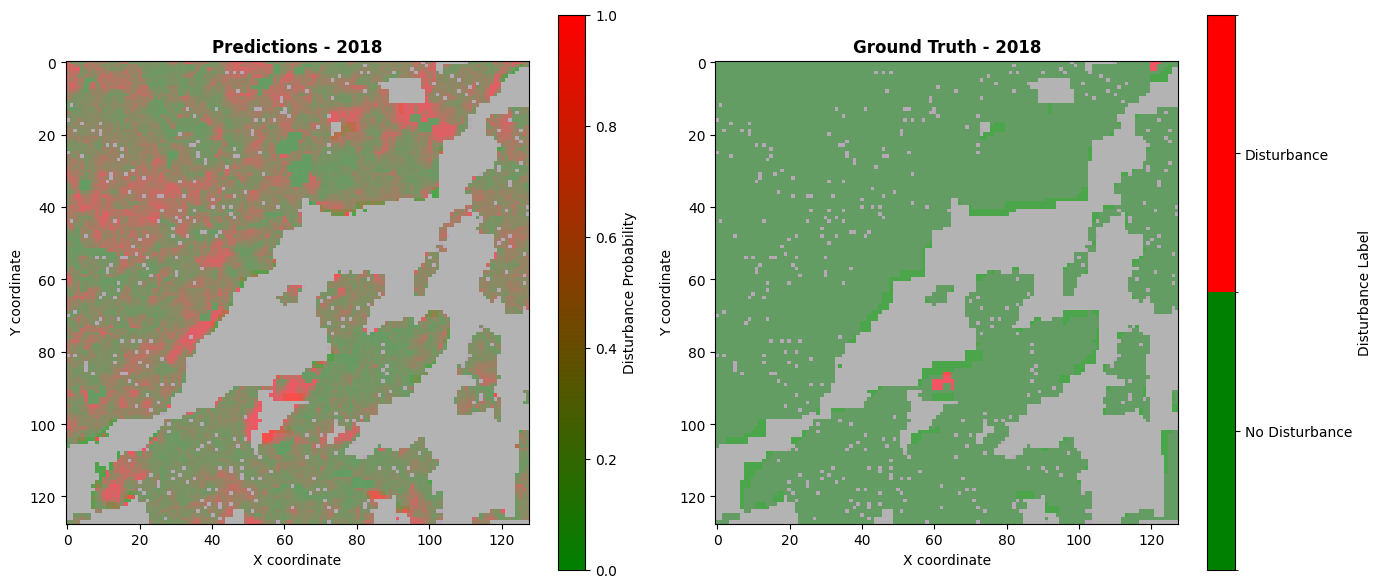


Processing year 2019 (index 3)...
  Saved: prediction visualizations prevyears monthly features\mc_15.24_58.63_1.3_20231018_0_2019.png


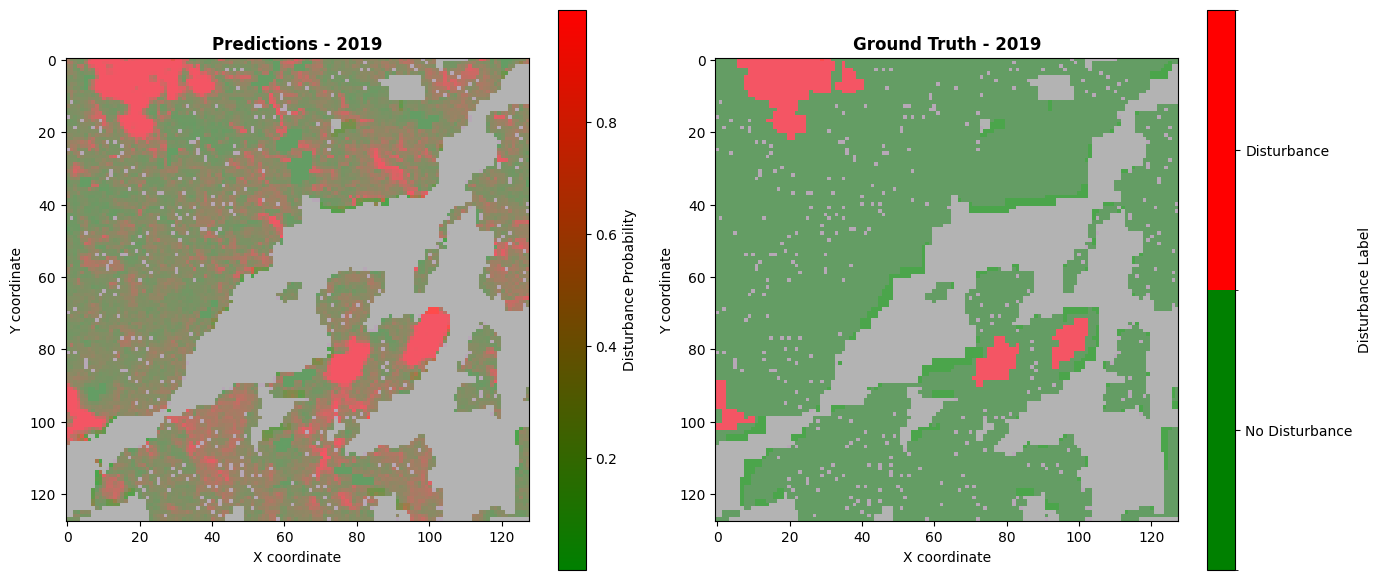


Processing year 2020 (index 4)...
  Saved: prediction visualizations prevyears monthly features\mc_15.24_58.63_1.3_20231018_0_2020.png


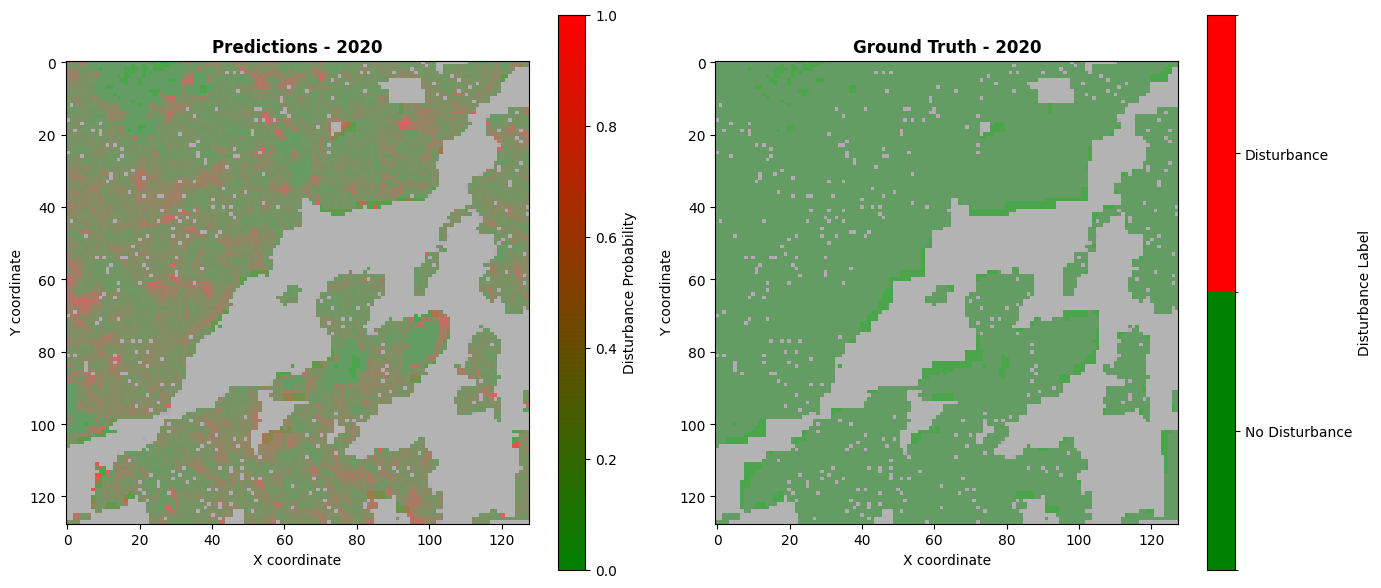


Processing year 2021 (index 5)...
  Saved: prediction visualizations prevyears monthly features\mc_15.24_58.63_1.3_20231018_0_2021.png


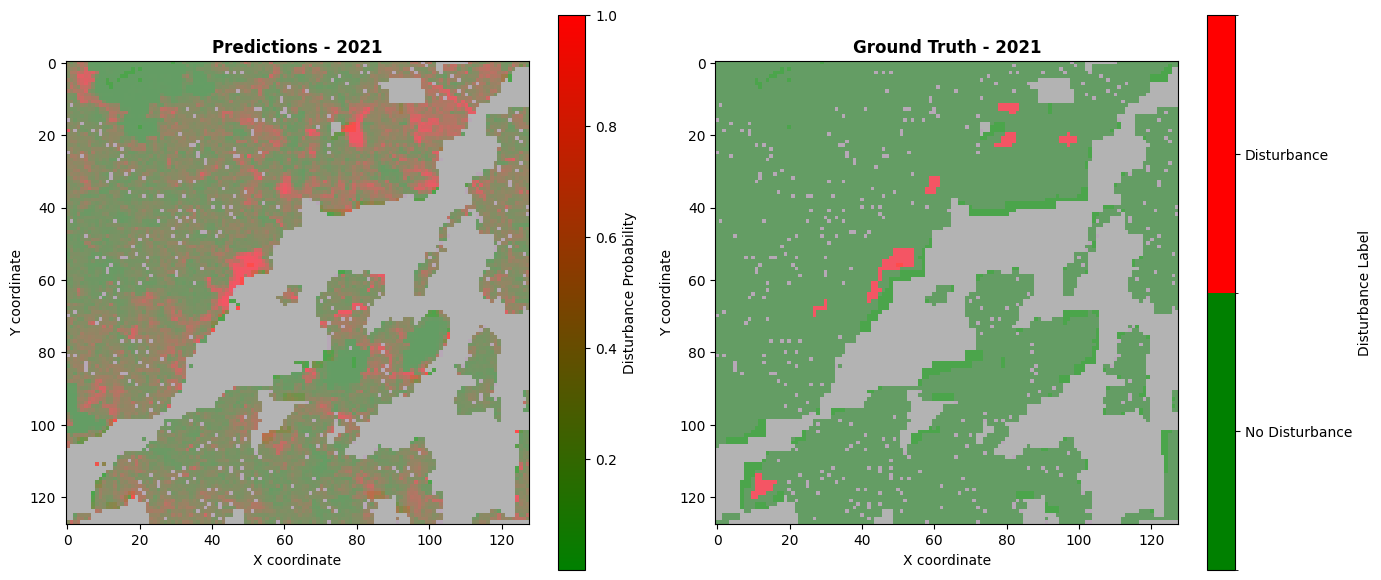


Processing year 2022 (index 6)...
  Saved: prediction visualizations prevyears monthly features\mc_15.24_58.63_1.3_20231018_0_2022.png


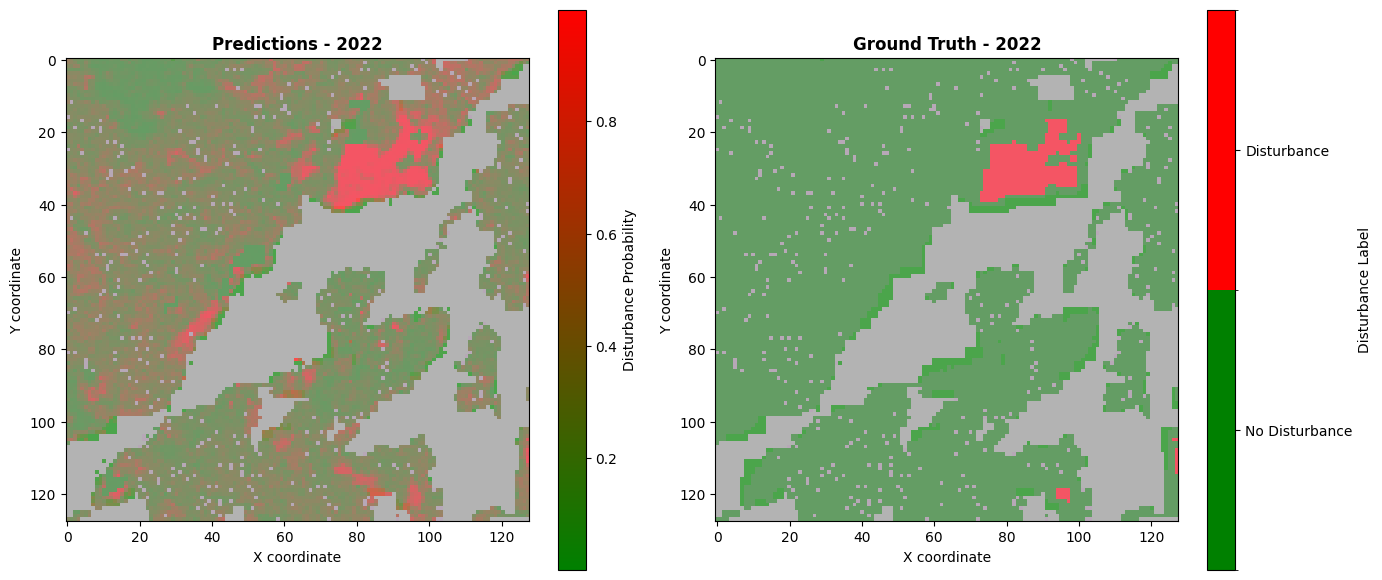


Visualization complete! Created 6 figures
Results saved to: c:\Users\bartu\Desktop\Fonda-scikit\prediction visualizations prevyears monthly features


In [105]:
# Create visualizations for all available years
print(f"Creating visualizations for cube: {selected_cube_name} (training idx: {selected_training_cube_idx})")
print(f"Cube contains {len(cube_pixels_indices)} pixels from training set")
print('=' * 60)

# Create output directory for visualizations
output_dir = OUTPUT_DIR
output_dir.mkdir(parents=True, exist_ok=True)

print('Run configuration:')
print(f"  Profile: {MODEL_PROFILE}")
print(f"  Models directory: {MODELS_DIR}")
print(f"  Features dataset: {FEATURES_ZARR_PATH}")
print(f"  Output directory: {output_dir.absolute()}")
print(f"  Available years (model + scaler + dataset): {available_years}\n")

# Create colormap
cmap, norm = create_custom_colormap()

# Store results
all_figures = []
results_by_year = {}

if 'year_values' in globals():
    dataset_years = [int(y) for y in year_values]
else:
    dataset_years = sorted(int(y) for y in year_to_idx.keys())

years_to_visualize = [year for year in dataset_years if year in available_years]

if not years_to_visualize:
    print('No years available for visualization after profile/data intersection check.')
    print(f'  Dataset years: {dataset_years}')
    print(f'  Available artifacts: {available_years}')

for year in years_to_visualize:
    year_idx = year_to_idx[year]

    # Load the model for this year
    model = load_year_model(year)
    if model is None:
        print(f"Skipping year {year} - model not found")
        continue

    # Load the scaler for this year
    year_scaler = get_scaler_for_year(year)
    if year_scaler is None:
        print(f"Skipping year {year} - scaler not found")
        continue

    print(f"\nProcessing year {year} (index {year_idx})...")

    try:
        # Get forest mask for this specific year
        forest_mask_year = forest_masks_by_year[year_idx, :, :]

        # Create visualization using the year-specific scaler
        fig, probabilities, ground_truth = visualize_year(
            year, year_idx, model, year_scaler, cube_pixels_indices, x_coords, y_coords,
            disturbances_all, forest_mask_year, grid_shape, cmap, norm
        )

        # Save the figure with cube name in filename
        filename = output_dir / f"{selected_cube_name}_{year}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"  Saved: {filename}")

        # Store results
        all_figures.append(fig)
        results_by_year[year] = {
            'probabilities': probabilities,
            'ground_truth': ground_truth,
            'figure': fig
        }

        # Display the figure in notebook (don't close it yet)
        plt.show()

    except Exception as e:
        print(f"  ERROR processing year {year}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'=' * 60}")
print(f"Visualization complete! Created {len(all_figures)} figures")
print(f"Results saved to: {output_dir.absolute()}")

In [106]:
# Add this after the visualization loop to analyze prediction distributions
print("\n" + "="*60)
print("PREDICTION DISTRIBUTION ANALYSIS")
print("="*60)

for year, stats in results_by_year.items():
    probs = stats['probabilities']
    print(f"\n{year}:")
    print(f"  Min probability: {probs.min():.4f}")
    print(f"  Max probability: {probs.max():.4f}")
    print(f"  Mean probability: {probs.mean():.4f}")
    print(f"  Std deviation: {probs.std():.4f}")
    print(f"  Median probability: {np.median(probs):.4f}")
    print(f"  % predictions < 0.3: {(probs < 0.3).sum() / len(probs) * 100:.1f}%")
    print(f"  % predictions > 0.7: {(probs > 0.7).sum() / len(probs) * 100:.1f}%")


PREDICTION DISTRIBUTION ANALYSIS

2017:
  Min probability: 0.0000
  Max probability: 0.9997
  Mean probability: 0.2398
  Std deviation: 0.1797
  Median probability: 0.1824
  % predictions < 0.3: 75.2%
  % predictions > 0.7: 3.8%

2018:
  Min probability: 0.0000
  Max probability: 1.0000
  Mean probability: 0.3061
  Std deviation: 0.2057
  Median probability: 0.2660
  % predictions < 0.3: 57.2%
  % predictions > 0.7: 5.5%

2019:
  Min probability: 0.0000
  Max probability: 1.0000
  Mean probability: 0.3242
  Std deviation: 0.2323
  Median probability: 0.2682
  % predictions < 0.3: 57.5%
  % predictions > 0.7: 8.6%

2020:
  Min probability: 0.0000
  Max probability: 1.0000
  Mean probability: 0.1844
  Std deviation: 0.1356
  Median probability: 0.1623
  % predictions < 0.3: 85.1%
  % predictions > 0.7: 0.8%

2021:
  Min probability: 0.0000
  Max probability: 1.0000
  Mean probability: 0.2573
  Std deviation: 0.1849
  Median probability: 0.2258
  % predictions < 0.3: 67.8%
  % prediction

# DIAGNOSTICS

In [107]:
# Diagnostic: Check what features look like
print('\n' + '='*60)
print('FEATURE DIAGNOSTICS')
print('='*60)

features_2017, features_with_nan_2017 = extract_features_for_cube_year(
    cube_pixels_indices, year_to_idx[2017], training_data_features
)

print(f"\n2017 Features shape: {features_2017.shape}")
print(f"% NaN values filled with 0: {np.sum(np.isnan(features_with_nan_2017)) / features_with_nan_2017.size * 100:.1f}%")
print('Feature value ranges:')
print(f"  Min: {features_2017.min():.4f}, Max: {features_2017.max():.4f}")
print(f"  Mean: {features_2017.mean():.4f}, Std: {features_2017.std():.4f}")

# Check DEM specifically
dem_idx_0 = training_data_features['dem'][cube_pixels_indices, 0:1]
dem_idx_1 = training_data_features['dem'][cube_pixels_indices, 1:2]
print(f"\nDEM at year_idx=0: {dem_idx_0[:5].ravel()}")
print(f"DEM at year_idx=1: {dem_idx_1[:5].ravel()}")
print(f"Are they identical? {np.allclose(dem_idx_0, dem_idx_1, equal_nan=True)}")


FEATURE DIAGNOSTICS

2017 Features shape: (11599, 32)
% NaN values filled with 0: 0.8%
Feature value ranges:
  Min: -7.5391, Max: 128.1062
  Mean: 3.2504, Std: 16.5680

DEM at year_idx=0: [ 90.97146606  80.50265503  75.04615021 104.39746094  79.16745758]
DEM at year_idx=1: [ 90.97146606  80.50265503  75.04615021 104.39746094  79.16745758]
Are they identical? True


DIAGNOSTIC

In [108]:
# DIAGNOSTIC: NaN percentage per feature (year 2017)
target_year = 2017
if target_year not in year_to_idx:
    raise ValueError(f"Year {target_year} not found in year_to_idx")

year_idx = year_to_idx[target_year]
_, features_with_nan = extract_features_for_cube_year(
    cube_pixels_indices, year_idx, training_data_features
)

# Build feature names in the same order as extract_features_for_cube_year
feature_names = []

# Current-year S2 bands
band_labels = training_data_features['s2_band'][:] if 's2_band' in training_data_features else []
band_labels = [b.decode('utf-8') if isinstance(b, (bytes, np.bytes_)) else str(b) for b in band_labels]
if band_labels:
    feature_names.extend([f"s2_{b}" for b in band_labels])
else:
    feature_names.extend([f"s2_band_{i}" for i in range(features_with_nan.shape[1])])

# DEM, NDVI, NDWI
feature_names.extend(['dem', 'ndvi', 'ndwi'])

# Last-year NDVI/NDWI
feature_names.extend(['ndvi_last_year', 'ndwi_last_year'])

# Last-year selected S2 bands
required_last_year_bands = ['B04', 'B03', 'B06']
feature_names.extend([f"s2_last_{b}" for b in required_last_year_bands])

# Optional NBR
if 'nbr' in training_data_features:
    feature_names.append('nbr')

# Optional deltas
if 'ndvi_delta' in training_data_features:
    feature_names.extend(['ndvi_delta', 'ndwi_delta'])
    if 'nbr_delta' in training_data_features:
        feature_names.append('nbr_delta')

# Optional temporal features
if 'years_since_last_disturbance' in training_data_features:
    feature_names.append('years_since_last_disturbance')
if 'log_years_since_last_disturbance' in training_data_features:
    feature_names.append('log_years_since_last_disturbance')
if 'ever_disturbed' in training_data_features:
    feature_names.append('ever_disturbed')

# Monthly yearly summary index features (if present in active dataset)
yearly_index_feature_names = [
    'ndvi_cv_year',
    'ndvi_max_m2m_drop_year',
    'ndvi_max_year',
    'ndvi_min_year',
    'ndvi_std_year',
    'ndwi_cv_year',
    'ndwi_max_m2m_drop_year',
    'ndwi_max_year',
    'ndwi_min_year',
    'ndwi_std_year',
]
for feature_name in yearly_index_feature_names:
    if feature_name in training_data_features:
        feature_names.append(feature_name)

# If lengths do not match, fall back to generic names
if len(feature_names) != features_with_nan.shape[1]:
    feature_names = [f"feature_{i}" for i in range(features_with_nan.shape[1])]

nan_pct_by_feature = np.mean(np.isnan(features_with_nan), axis=0) * 100.0
print('\n' + '=' * 60)
print(f"NaN percentage per feature for year {target_year} ({MODEL_PROFILE} profile)")
print('=' * 60)
for name, pct in zip(feature_names, nan_pct_by_feature):
    print(f"{name}: {pct:.1f}%")


NaN percentage per feature for year 2017 (monthly profile)
s2_B02: 2.4%
s2_B03: 2.4%
s2_B04: 2.4%
s2_B05: 2.4%
s2_B06: 2.4%
s2_B07: 2.4%
s2_B8A: 2.4%
dem: 0.0%
ndvi: 2.4%
ndwi: 2.4%
ndvi_last_year: 0.0%
ndwi_last_year: 0.0%
s2_last_B04: 0.0%
s2_last_B03: 0.0%
s2_last_B06: 0.0%
nbr: 2.4%
ndvi_delta: 0.0%
ndwi_delta: 0.0%
nbr_delta: 0.0%
years_since_last_disturbance: 0.0%
log_years_since_last_disturbance: 0.0%
ever_disturbed: 0.0%
ndvi_cv_year: 0.0%
ndvi_max_m2m_drop_year: 0.7%
ndvi_max_year: 0.0%
ndvi_min_year: 0.0%
ndvi_std_year: 0.0%
ndwi_cv_year: 0.0%
ndwi_max_m2m_drop_year: 0.7%
ndwi_max_year: 0.0%
ndwi_min_year: 0.0%
ndwi_std_year: 0.0%


## TABLE 2 Threshold Recompute + Binary Prediction Maps

Recompute `best_threshold` in this notebook using validation PR/F1 (same logic as classifier Table 2 flow), then render binary prediction maps (`green=0`, `red=1`) instead of probability spectrum.

In [109]:
# Recompute per-year best thresholds from validation PR curve (dynamic year-wise logic)
from sklearn.metrics import precision_recall_curve, average_precision_score

required_objects = {
    'data_split': "Run data split loading cell first.",
    'available_years': "Run model/scaler discovery cell first.",
    'year_to_idx': "Run year mapping cell first.",
    'training_data_features': "Run feature dataset loading cell first.",
    'extract_features_for_cube_year': "Run feature extraction function cell first.",
    'get_scaler_for_year': "Run profile-aware loader cell first.",
    'load_year_model': "Run profile-aware loader cell first.",
    'MODEL_PROFILE': "Run runtime profile configuration cell first.",
}
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    missing_help = "\n".join([f"- {name}: {required_objects[name]}" for name in missing_objects])
    raise RuntimeError(
        "Missing required objects for per-year threshold recomputation:\n"
        f"{missing_help}"
    )

# Pull validation indices from already-loaded split if possible.
if 'val_pixel_indices' in globals():
    val_pixel_indices = np.asarray(globals()['val_pixel_indices'])
elif isinstance(data_split, np.lib.npyio.NpzFile) and ('val_pixel_indices' in data_split.files):
    val_pixel_indices = np.asarray(data_split['val_pixel_indices'])
else:
    split_data_local = np.load('data_split.npz', allow_pickle=True)
    if 'val_pixel_indices' not in split_data_local.files:
        raise KeyError("'val_pixel_indices' not found in data_split.npz")
    val_pixel_indices = np.asarray(split_data_local['val_pixel_indices'])

val_pixel_indices = np.asarray(val_pixel_indices).reshape(-1)

threshold_by_year = {}
validation_stats_by_year = {}
fallback_reasons_by_year = {}
skipped_years = []

print('=' * 80)
print('RECOMPUTE PER-YEAR THRESHOLDS (VALIDATION PR/F1)')
print('=' * 80)
print(f"Profile: {MODEL_PROFILE}")
print(f"Validation pixels: {len(val_pixel_indices)}")

for year in sorted(int(y) for y in available_years):
    if year not in year_to_idx:
        print(f"Year {year}: skipped (not in year_to_idx)")
        skipped_years.append(year)
        continue

    year_idx = int(year_to_idx[year])
    year_scaler = get_scaler_for_year(year)
    year_model = load_year_model(year)

    if year_scaler is None:
        print(f"Year {year}: skipped (scaler unavailable)")
        skipped_years.append(year)
        continue
    if year_model is None:
        print(f"Year {year}: skipped (model unavailable)")
        skipped_years.append(year)
        continue

    features_for_pred, features_with_nan = extract_features_for_cube_year(
        val_pixel_indices,
        year_idx,
        training_data_features,
    )

    expected_features = getattr(year_scaler, 'n_features_in_', None)
    if expected_features is not None and features_for_pred.shape[1] != int(expected_features):
        raise ValueError(
            f"Feature count mismatch for validation year {year}: extracted "
            f"{features_for_pred.shape[1]} but scaler expects {int(expected_features)}."
        )

    y_val_year = np.asarray(training_data_features['disturbances'][val_pixel_indices, year_idx]).reshape(-1)

    # Keep only valid labels and exclude rows with unresolved NaNs.
    valid_label_mask = np.isin(y_val_year, [0, 1])
    valid_feature_mask = ~np.any(np.isnan(features_with_nan), axis=1)
    valid_mask = valid_label_mask & valid_feature_mask

    n_valid = int(valid_mask.sum())
    if n_valid == 0:
        fallback_reasons_by_year[year] = 'no valid validation samples after filtering'
        validation_stats_by_year[year] = {
            'year': year,
            'n_val_samples': 0,
            'n_positive': 0,
            'positive_rate': np.nan,
            'proba_mean': np.nan,
            'auprc': np.nan,
            'threshold': np.nan,
            'f1_max': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'fallback_used': True,
            'fallback_reason': fallback_reasons_by_year[year],
        }
        print(f"Year {year}: queued for fallback ({fallback_reasons_by_year[year]})")
        continue

    X_val_scaled = year_scaler.transform(features_for_pred[valid_mask])
    y_val_clean = y_val_year[valid_mask].astype(np.int64)
    y_val_proba = year_model.predict_proba(X_val_scaled)[:, 1]

    positive_rate = float((y_val_clean == 1).mean())

    if len(np.unique(y_val_clean)) < 2:
        fallback_reasons_by_year[year] = 'single-class validation labels'
        validation_stats_by_year[year] = {
            'year': year,
            'n_val_samples': n_valid,
            'n_positive': int((y_val_clean == 1).sum()),
            'positive_rate': positive_rate,
            'proba_mean': float(np.mean(y_val_proba)),
            'auprc': np.nan,
            'threshold': np.nan,
            'f1_max': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'fallback_used': True,
            'fallback_reason': fallback_reasons_by_year[year],
        }
        print(f"Year {year}: queued for fallback ({fallback_reasons_by_year[year]})")
        continue

    year_auprc = float(average_precision_score(y_val_clean, y_val_proba))
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_val_clean, y_val_proba)
    f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)
    best_idx = int(np.argmax(f1_vals))
    year_threshold = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5

    threshold_by_year[year] = year_threshold
    validation_stats_by_year[year] = {
        'year': year,
        'n_val_samples': n_valid,
        'n_positive': int((y_val_clean == 1).sum()),
        'positive_rate': positive_rate,
        'proba_mean': float(np.mean(y_val_proba)),
        'auprc': year_auprc,
        'threshold': year_threshold,
        'f1_max': float(f1_vals[best_idx]),
        'precision': float(precision_vals[best_idx]),
        'recall': float(recall_vals[best_idx]),
        'fallback_used': False,
        'fallback_reason': '',
    }

    print(
        f"Year {year}: threshold={year_threshold:.4f} | "
        f"n={n_valid} | pos_rate={positive_rate:.4f} | "
        f"AUPRC={year_auprc:.4f}"
    )

if len(threshold_by_year) == 0:
    raise RuntimeError(
        'No per-year thresholds could be computed from validation data. '
        'Check model/scaler artifacts and validation labels.'
    )

fallback_years = sorted(int(y) for y in fallback_reasons_by_year.keys())
fallback_threshold = float(np.mean(list(threshold_by_year.values()))) if fallback_years else np.nan

for year in fallback_years:
    threshold_by_year[year] = fallback_threshold
    year_stats = validation_stats_by_year.setdefault(year, {'year': year})
    year_stats['threshold'] = fallback_threshold
    year_stats['fallback_used'] = True
    year_stats['fallback_reason'] = fallback_reasons_by_year[year]
    year_stats['fallback_value'] = fallback_threshold

print('\n' + '-' * 80)
print('PER-YEAR THRESHOLD SUMMARY')
print('-' * 80)
for year in sorted(int(y) for y in threshold_by_year.keys()):
    year_stats = validation_stats_by_year.get(year, {})
    threshold_used = float(threshold_by_year[year])
    n_samples = int(year_stats.get('n_val_samples', 0))
    positive_rate = year_stats.get('positive_rate', np.nan)
    auprc = year_stats.get('auprc', np.nan)
    f1_max = year_stats.get('f1_max', np.nan)
    fallback_tag = ' [fallback]' if year_stats.get('fallback_used', False) else ''

    print(
        f"Year {year}: threshold={threshold_used:.4f}{fallback_tag} | "
        f"n={n_samples} | pos_rate={positive_rate:.4f} | "
        f"AUPRC={auprc:.4f} | F1={f1_max:.4f}"
    )

if fallback_years:
    print('\nFallback assignment (mean threshold):')
    print(f"  Mean threshold from computed years: {fallback_threshold:.4f}")
    for year in fallback_years:
        print(f"  Year {year}: {fallback_reasons_by_year[year]} -> {fallback_threshold:.4f}")

if skipped_years:
    print('\nSkipped years (missing mapping/artifacts):')
    print(f"  {sorted(int(y) for y in skipped_years)}")

print('-' * 80)
print(f"Threshold years available: {sorted(int(y) for y in threshold_by_year.keys())}")
print(f"Threshold range: {min(threshold_by_year.values()):.4f} to {max(threshold_by_year.values()):.4f}")
print(f"Validation pixels considered: {len(val_pixel_indices)}")
print('-' * 80)

RECOMPUTE PER-YEAR THRESHOLDS (VALIDATION PR/F1)
Profile: monthly
Validation pixels: 1273437
Year 2017: threshold=0.8685 | n=1270825 | pos_rate=0.0188 | AUPRC=0.0840
Year 2018: threshold=0.9172 | n=1271706 | pos_rate=0.0221 | AUPRC=0.3666
Year 2019: threshold=0.8708 | n=1271570 | pos_rate=0.0183 | AUPRC=0.3653
Year 2020: threshold=0.8968 | n=1271629 | pos_rate=0.0169 | AUPRC=0.4112
Year 2021: threshold=0.9099 | n=1271639 | pos_rate=0.0156 | AUPRC=0.3860
Year 2022: threshold=0.9019 | n=1272609 | pos_rate=0.0288 | AUPRC=0.2914

--------------------------------------------------------------------------------
PER-YEAR THRESHOLD SUMMARY
--------------------------------------------------------------------------------
Year 2017: threshold=0.8685 | n=1270825 | pos_rate=0.0188 | AUPRC=0.0840 | F1=0.1597
Year 2018: threshold=0.9172 | n=1271706 | pos_rate=0.0221 | AUPRC=0.3666 | F1=0.4006
Year 2019: threshold=0.8708 | n=1271570 | pos_rate=0.0183 | AUPRC=0.3653 | F1=0.4257
Year 2020: threshold=0.8

BINARY PREDICTION MAPS (PER-YEAR DYNAMIC THRESHOLDS)
Threshold years available: [2017, 2018, 2019, 2020, 2021, 2022]
Output directory: C:\Users\bartu\Desktop\Fonda-scikit\prediction visualizations prevyears monthly features\binary_recomputed_table2_threshold


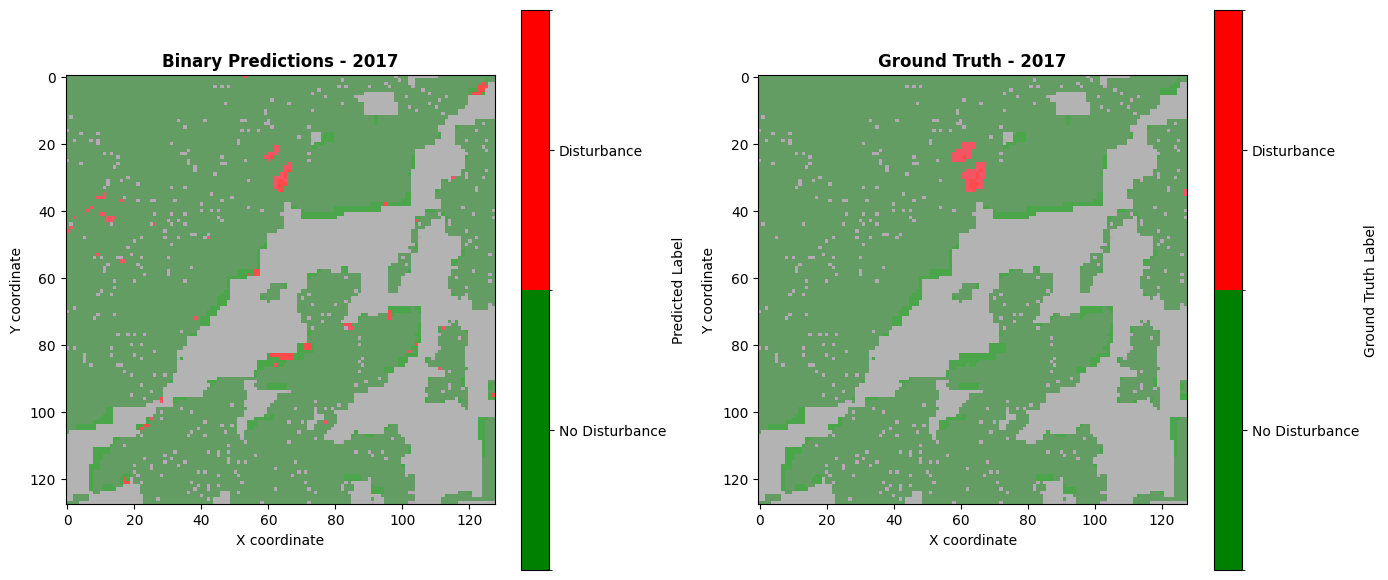

Year 2017: threshold=0.8685 | saved mc_15.24_58.63_1.3_20231018_0_2017_binary_t0.8685.png | positive=114/11599 (0.0098)


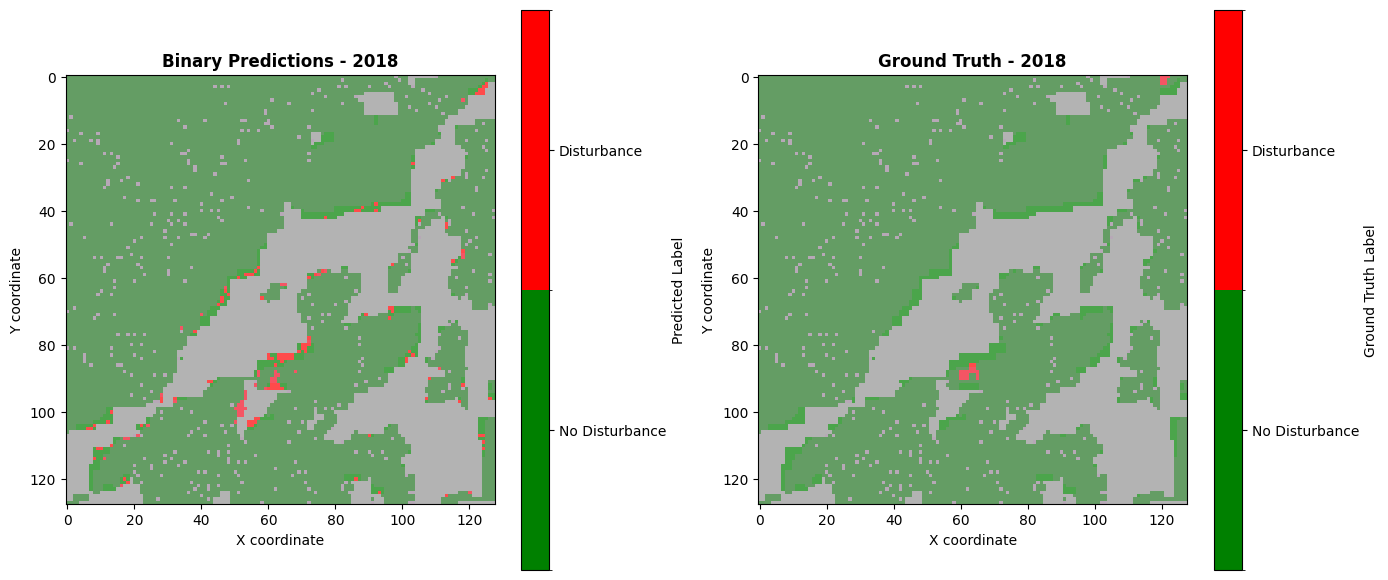

Year 2018: threshold=0.9172 | saved mc_15.24_58.63_1.3_20231018_0_2018_binary_t0.9172.png | positive=164/11599 (0.0141)


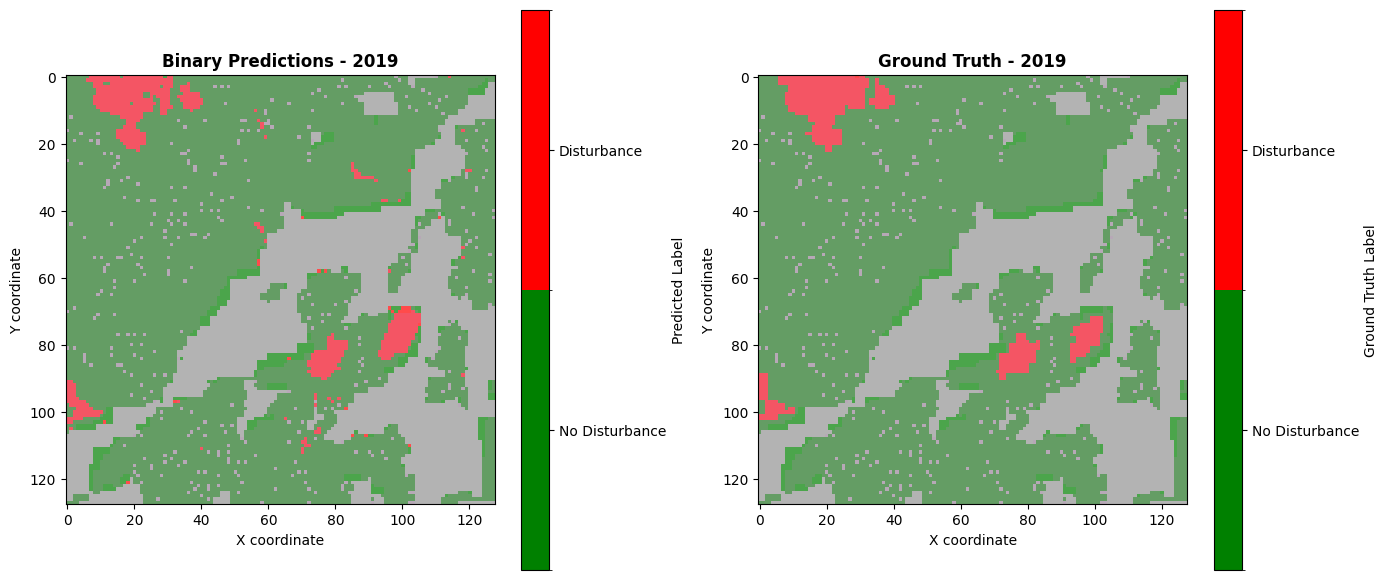

Year 2019: threshold=0.8708 | saved mc_15.24_58.63_1.3_20231018_0_2019_binary_t0.8708.png | positive=696/11599 (0.0600)


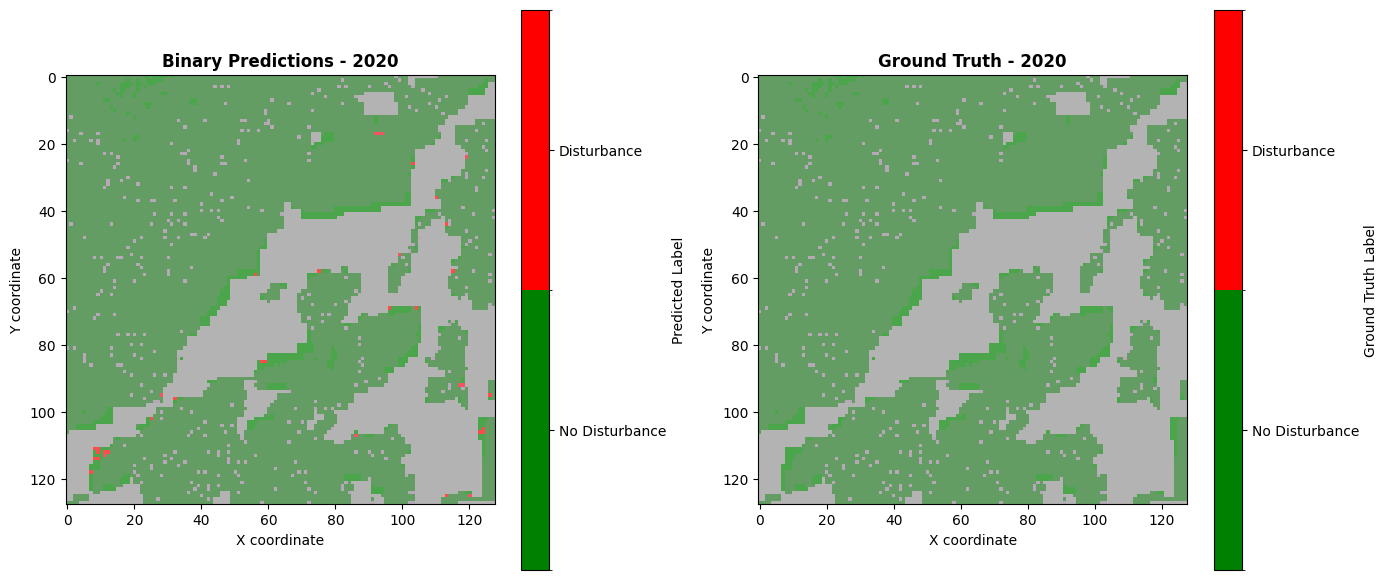

Year 2020: threshold=0.8968 | saved mc_15.24_58.63_1.3_20231018_0_2020_binary_t0.8968.png | positive=36/11599 (0.0031)


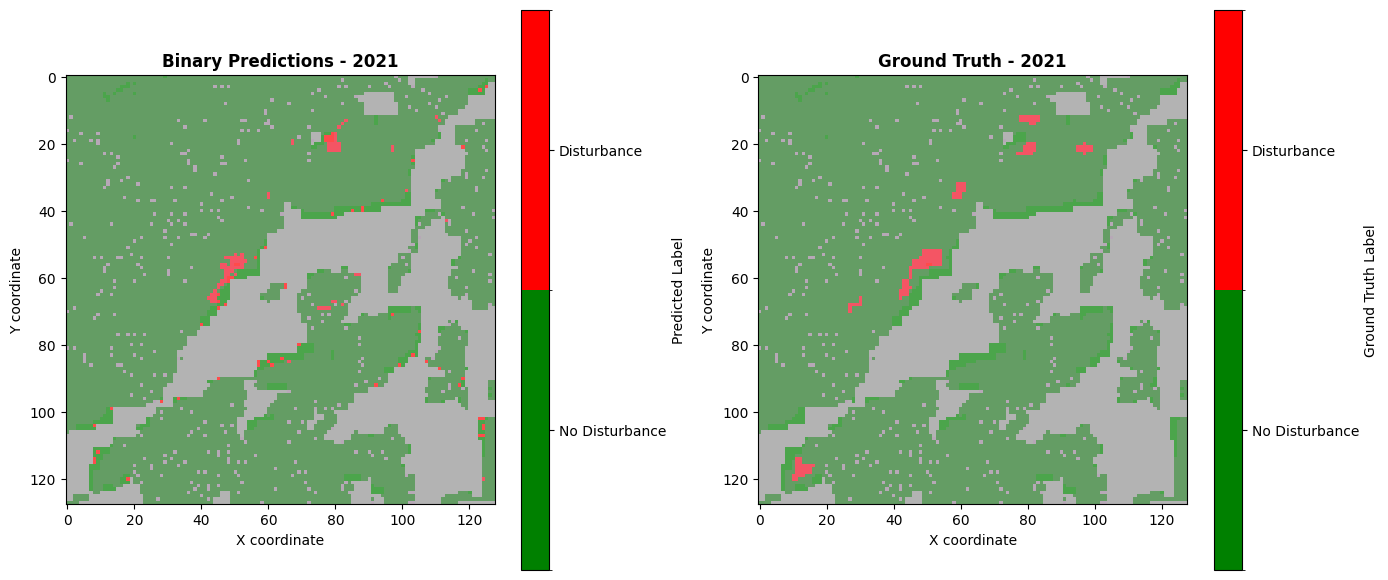

Year 2021: threshold=0.9099 | saved mc_15.24_58.63_1.3_20231018_0_2021_binary_t0.9099.png | positive=143/11599 (0.0123)


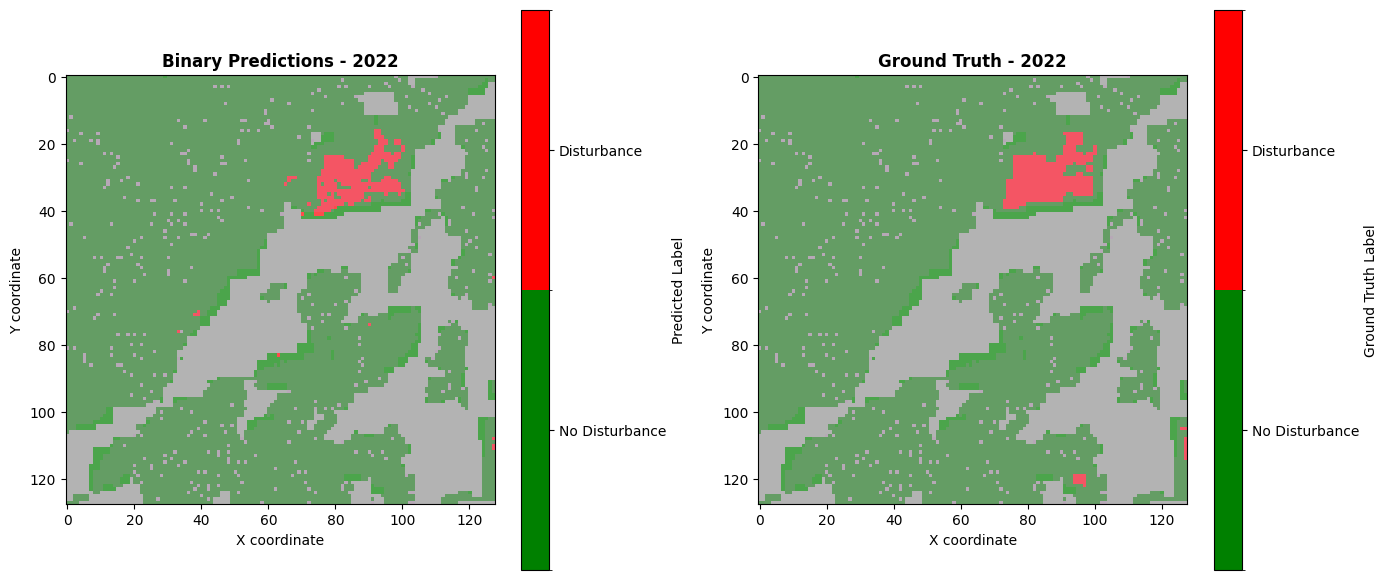

Year 2022: threshold=0.9019 | saved mc_15.24_58.63_1.3_20231018_0_2022_binary_t0.9019.png | positive=316/11599 (0.0272)

--------------------------------------------------------------------------------
Created 6 binary figures
Thresholds used by year:
  2017: 0.8685
  2018: 0.9172
  2019: 0.8708
  2020: 0.8968
  2021: 0.9099
  2022: 0.9019
Saved outputs to: C:\Users\bartu\Desktop\Fonda-scikit\prediction visualizations prevyears monthly features\binary_recomputed_table2_threshold
--------------------------------------------------------------------------------


In [110]:
# Render binary prediction maps using per-year dynamic thresholds
required_binary_objects = {
    'threshold_by_year': "Run the per-year threshold recomputation cell in this section first.",
    'results_by_year': "Run the main yearly visualization loop first.",
    'years_to_visualize': "Run the main yearly visualization loop first.",
    'year_to_idx': "Run year mapping cell first.",
    'forest_masks_by_year': "Run forest-mask loading cell first.",
    'x_coords': "Run cube selection/spatial extraction cells first.",
    'y_coords': "Run cube selection/spatial extraction cells first.",
    'grid_shape': "Run spatial grid setup cell first.",
    'OUTPUT_DIR': "Run profile configuration cell first.",
    'selected_cube_name': "Run cube selection cell first.",
}
missing_binary_objects = [name for name in required_binary_objects if name not in globals()]
if missing_binary_objects:
    missing_help = "\n".join([f"- {name}: {required_binary_objects[name]}" for name in missing_binary_objects])
    raise RuntimeError(
        "Missing required objects for binary visualization:\n"
        f"{missing_help}"
    )

if 'validation_stats_by_year' not in globals():
    validation_stats_by_year = {}

binary_output_dir = OUTPUT_DIR / 'binary_recomputed_table2_threshold'
binary_output_dir.mkdir(parents=True, exist_ok=True)

binary_cmap = ListedColormap(['green', 'red'])
binary_norm = BoundaryNorm([0, 0.5, 1.0], 2)

binary_results_by_year = {}
binary_figures = []
rendered_year_thresholds = {}

print('=' * 80)
print('BINARY PREDICTION MAPS (PER-YEAR DYNAMIC THRESHOLDS)')
print('=' * 80)
print(f"Threshold years available: {sorted(int(y) for y in threshold_by_year.keys())}")
print(f"Output directory: {binary_output_dir.resolve()}")

for year in years_to_visualize:
    if year not in results_by_year:
        print(f"Year {year}: skipped (missing probabilities in results_by_year)")
        continue
    if year not in year_to_idx:
        print(f"Year {year}: skipped (not in year_to_idx)")
        continue
    if year not in threshold_by_year:
        print(f"Year {year}: skipped (no threshold available in threshold_by_year)")
        continue

    year_threshold = float(threshold_by_year[year])
    rendered_year_thresholds[int(year)] = year_threshold

    year_idx = int(year_to_idx[year])
    probabilities = np.asarray(results_by_year[year]['probabilities'], dtype=np.float64)
    ground_truth = np.asarray(results_by_year[year]['ground_truth'], dtype=np.float64)

    valid_prob_mask = ~np.isnan(probabilities)
    binary_pred = np.full(probabilities.shape, np.nan, dtype=np.float64)
    binary_pred[valid_prob_mask] = (probabilities[valid_prob_mask] >= year_threshold).astype(np.float64)

    finite_values = binary_pred[~np.isnan(binary_pred)]
    if finite_values.size > 0:
        unique_vals = set(np.unique(finite_values).tolist())
        if not unique_vals.issubset({0.0, 1.0}):
            raise ValueError(f"Year {year}: binary prediction contains non-binary values: {sorted(unique_vals)}")

    pred_grid = create_spatial_grid_with_nan(x_coords, y_coords, binary_pred, grid_shape)
    gt_grid = create_spatial_grid_with_nan(x_coords, y_coords, ground_truth, grid_shape)

    forest_mask_year = forest_masks_by_year[year_idx, :, :]
    forest_overlay = create_forest_mask_overlay(forest_mask_year, alpha=0.2)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Binary predictions
    im1 = ax1.imshow(pred_grid, cmap=binary_cmap, norm=binary_norm, origin='upper')
    nan_mask_pred = np.isnan(pred_grid)
    ax1.imshow(
        np.where(nan_mask_pred[:, :, None], 0, 1),
        cmap='gray',
        origin='upper',
        vmin=0,
        vmax=1,
        alpha=0.3,
    )
    ax1.imshow(forest_overlay, origin='upper')
    ax1.set_title(f'Binary Predictions - {year}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X coordinate')
    ax1.set_ylabel('Y coordinate')
    cbar1 = plt.colorbar(im1, ax=ax1, label='Predicted Label', ticks=[0.25, 0.75])
    cbar1.set_ticklabels(['No Disturbance', 'Disturbance'])

    # Plot 2: Ground truth
    im2 = ax2.imshow(gt_grid, cmap=binary_cmap, norm=binary_norm, origin='upper')
    nan_mask_gt = np.isnan(gt_grid)
    ax2.imshow(
        np.where(nan_mask_gt[:, :, None], 0, 1),
        cmap='gray',
        origin='upper',
        vmin=0,
        vmax=1,
        alpha=0.3,
    )
    ax2.imshow(forest_overlay, origin='upper')
    ax2.set_title(f'Ground Truth - {year}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('X coordinate')
    ax2.set_ylabel('Y coordinate')
    cbar2 = plt.colorbar(im2, ax=ax2, label='Ground Truth Label', ticks=[0.25, 0.75])
    cbar2.set_ticklabels(['No Disturbance', 'Disturbance'])

    plt.tight_layout()

    filename = binary_output_dir / f"{selected_cube_name}_{year}_binary_t{year_threshold:.4f}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

    valid_pixels = int(np.sum(valid_prob_mask))
    positive_predictions = int(np.nansum(binary_pred))
    positive_rate = (positive_predictions / valid_pixels) if valid_pixels > 0 else np.nan

    year_validation_stats = validation_stats_by_year.get(int(year), {})
    fallback_used = bool(year_validation_stats.get('fallback_used', False))
    fallback_reason = year_validation_stats.get('fallback_reason', '')

    validation_n_samples = int(year_validation_stats.get('n_val_samples', 0))
    validation_positive_rate = year_validation_stats.get('positive_rate', np.nan)
    validation_auprc = year_validation_stats.get('auprc', np.nan)
    validation_f1 = year_validation_stats.get('f1_max', np.nan)

    binary_figures.append(fig)
    binary_results_by_year[int(year)] = {
        'threshold_used': year_threshold,
        'valid_pixels': valid_pixels,
        'positive_predictions': positive_predictions,
        'positive_rate': float(positive_rate) if valid_pixels > 0 else np.nan,
        'saved_path': str(filename),
        'validation_n_samples': validation_n_samples,
        'validation_positive_rate': float(validation_positive_rate) if np.isfinite(validation_positive_rate) else np.nan,
        'validation_auprc': float(validation_auprc) if np.isfinite(validation_auprc) else np.nan,
        'validation_f1_max': float(validation_f1) if np.isfinite(validation_f1) else np.nan,
        'fallback_used': fallback_used,
        'fallback_reason': fallback_reason,
    }

    fallback_tag = ' [fallback]' if fallback_used else ''
    print(
        f"Year {year}: threshold={year_threshold:.4f}{fallback_tag} | saved {filename.name} | "
        f"positive={positive_predictions}/{valid_pixels} ({positive_rate:.4f})"
    )

print('\n' + '-' * 80)
print(f"Created {len(binary_figures)} binary figures")
if rendered_year_thresholds:
    print('Thresholds used by year:')
    for year in sorted(rendered_year_thresholds.keys()):
        print(f"  {year}: {rendered_year_thresholds[year]:.4f}")
print(f"Saved outputs to: {binary_output_dir.resolve()}")
print('-' * 80)